### 노드 캐싱

노드 캐싱은 계산 결과를 저장하여 재사용하는 최적화 기법입니다.

**CachePolicy 설정**

**ttl (Time To Live)**
```python
ttl=60  # 60초 동안 캐시 유지
ttl=None  # 무제한 캐시 유지
```

**key_func (캐시 키 생성)**
```python
# 기본: 전체 입력을 키로 사용
key_func=None

# 커스텀: 특정 필드만 키로 사용
key_func=lambda state: hash(state["user_id"])
```

**사용 시나리오**

- 계산이 오래 걸리는 작업
- 결과가 자주 반복되는 경우
- 외부 API 호출 비용 절감
- 자주 조회되는 데이터베이스 쿼리

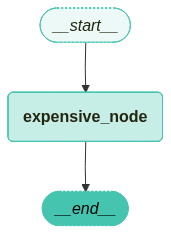

In [1]:
from feature.NodeCaching import NodeCaching

workflow = NodeCaching()
workflow.show_graph()


In [2]:
import time

print("\n캐싱 테스트:")
print("첫 번째 실행")
start_time = time.time()
result1 = workflow.invoke({"x": 10})
print(f"  결과: {result1['result']}, 소요 시간: {time.time() - start_time:.1f}초")

print("\n두 번째 실행")
start_time = time.time()
result2 = workflow.invoke({"x": 10})
print(f"  결과: {result2['result']}, 소요 시간: {time.time() - start_time:.1f}초")

print("\n다른 입력으로 실행")
start_time = time.time()
result3 = workflow.invoke({"x": 20})
print(f"  결과: {result3['result']}, 소요 시간: {time.time() - start_time:.1f}초")


캐싱 테스트:
첫 번째 실행
  무거운 계산 실행 중... (x=10)

🔄 Node: expensive_node 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
result:
100
  결과: 100, 소요 시간: 3.0초

두 번째 실행

🔄 Node: expensive_node 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
result:
100

🔄 Node: __metadata__ 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
cached:
True
  결과: 100, 소요 시간: 0.0초

다른 입력으로 실행
  무거운 계산 실행 중... (x=20)

🔄 Node: expensive_node 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
result:
400
  결과: 400, 소요 시간: 3.0초
